# Module 1 Lab

## Using the Students dataset from the book website

In [2]:
# Import necessary libraries - common libraries include pandas, numpy, matplotlib, and sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
import math
import scipy.stats
from sklearn.linear_model import LinearRegression

In [7]:
# Read in the Students data file
students = pd.read_csv('http://stat4ds.rwth-aachen.de/data/Students.dat', sep=r'\s+')

# View the first few rows of the dataset
students.head()

students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   subject  60 non-null     int64  
 1   gender   60 non-null     int64  
 2   age      60 non-null     int64  
 3   hsgpa    60 non-null     float64
 4   cogpa    60 non-null     float64
 5   dhome    60 non-null     int64  
 6   dres     60 non-null     float64
 7   tv       60 non-null     float64
 8   sport    60 non-null     int64  
 9   news     60 non-null     int64  
 10  aids     60 non-null     int64  
 11  veg      60 non-null     int64  
 12  affil    60 non-null     int64  
 13  ideol    60 non-null     int64  
 14  relig    60 non-null     int64  
 15  abor     60 non-null     int64  
 16  affirm   60 non-null     int64  
 17  life     60 non-null     int64  
dtypes: float64(4), int64(14)
memory usage: 8.6 KB


In [11]:
# Calculate summary statistics
# students.describe(include='all') => Includes categorical/text columns too.
# students.describe().T => inverts the view (transposes) - better readability
students.describe().T

,count,mean,std,min,25%,50%,75%,max
subject,60.0,30.500000,17.464249,1.0,15.750,30.50,45.250,60.0
gender,60.0,0.516667,0.503939,0.0,0.000,1.00,1.000,1.0
age,60.0,29.166667,8.475621,22.0,24.000,26.50,31.000,71.0
hsgpa,60.0,3.308333,0.459658,2.0,3.000,3.35,3.625,4.0
cogpa,60.0,3.453333,0.351494,2.6,3.175,3.50,3.725,4.0
dhome,60.0,1232.200000,1681.747949,0.0,205.000,640.00,1350.000,8000.0
dres,60.0,3.818333,4.117902,0.2,1.450,2.00,5.000,20.0
tv,60.0,7.266667,6.717336,0.0,3.000,6.00,10.000,37.0
sport,60.0,5.483333,3.872947,0.0,3.000,5.00,7.000,16.0
news,60.0,4.083333,3.004469,0.0,2.000,3.00,5.250,14.0


In [20]:
# Plotting function for discrete variables
def discrete_plots(df, columns, num_cols):
    n_plots = len(columns)
    n_cols = num_cols
    n_rows = int(math.ceil(n_plots/n_cols))
    gs = gridspec.GridSpec(n_rows, n_cols)
    fig = plt.figure(figsize=(12,8))
    for i in range(n_plots):
        ax = fig.add_subplot(gs[i])
        df[columns[i]].value_counts().sort_index().plot(kind='bar', ax=ax)
        ax.set_xlabel(columns[i])
    fig.tight_layout()
    fig.supylabel('Count')
    plt.show()


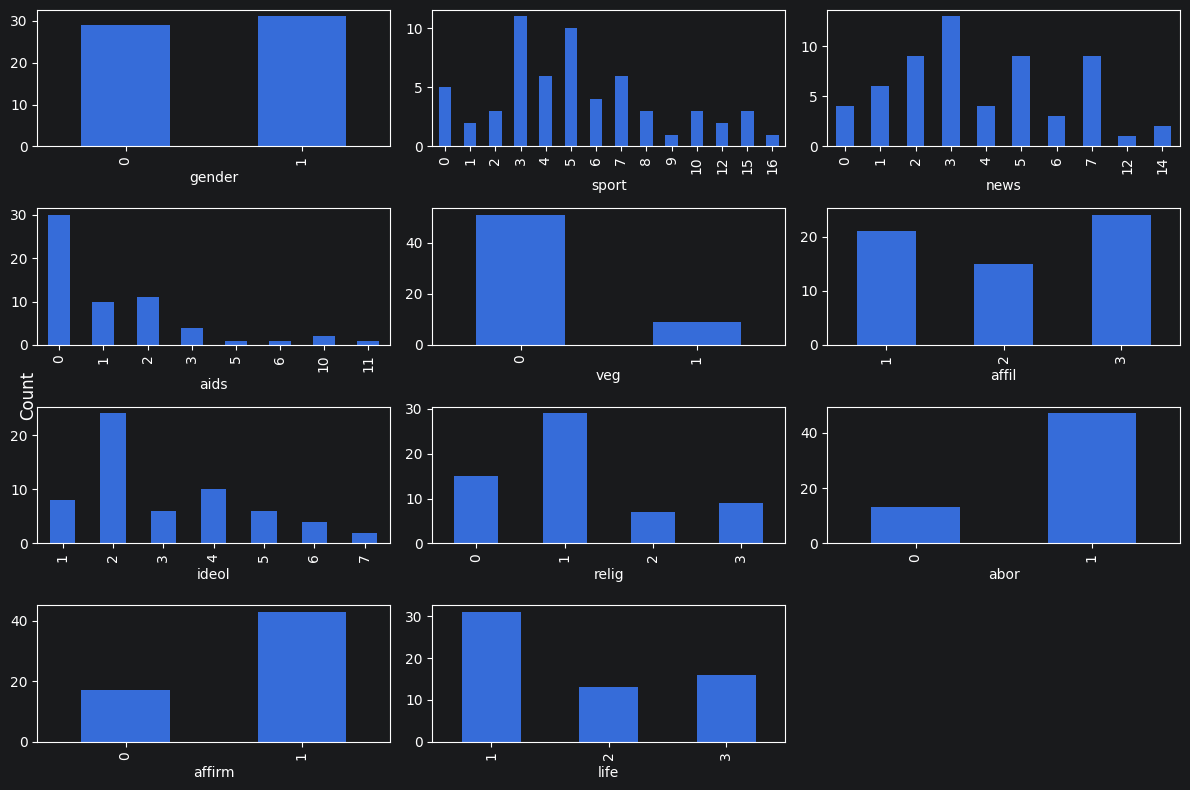

In [21]:
# Plot discrete variables
discrete_plots(students, ['gender', 'sport', 'news', 'aids', 'veg', 'affil', 'ideol', 'relig', 'abor', 'affirm', 'life'], 3)

In [30]:
# Plotting function for continuous variables
def continuous_plots(df, columns, num_cols):
    n_plots = len(columns)
    n_cols = num_cols
    n_rows = int(math.ceil(n_plots/n_cols))
    gs = gridspec.GridSpec(n_rows, n_cols)
    fig = plt.figure(figsize=(12,8))
    for i in range(n_plots):
        ax = fig.add_subplot(gs[i])
        df[columns[i]].hist(ax=ax, grid=False)
        ax.set_xlabel(columns[i])
    fig.tight_layout()
    fig.supylabel('Count')
    plt.show()

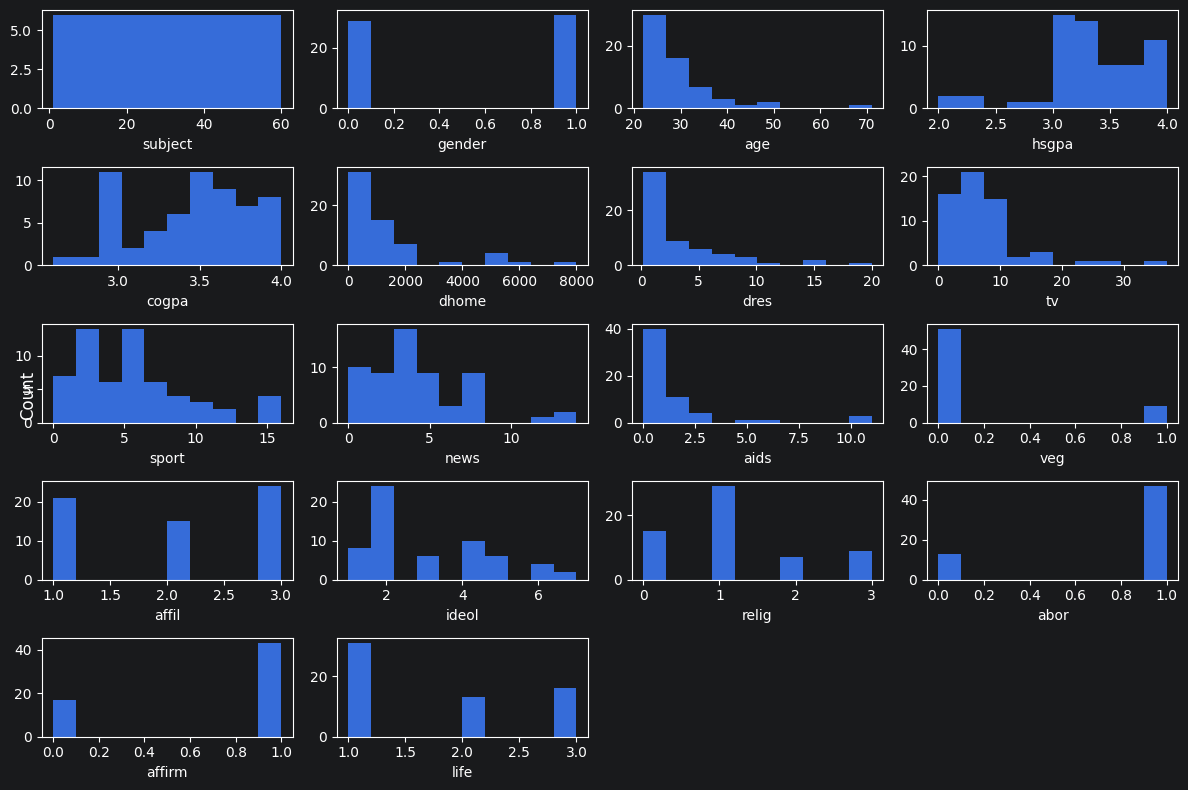

In [31]:
# Plot continuous variables
continuous_plots(students, students.columns, 4)

## 1.21

### For the Students data file introduced in Exercise 1.2, summarize the relationship between hsgpa and cogpa using correlation and regression. Find the predicted college GPA of a student who had a high school GPA of 4.0.

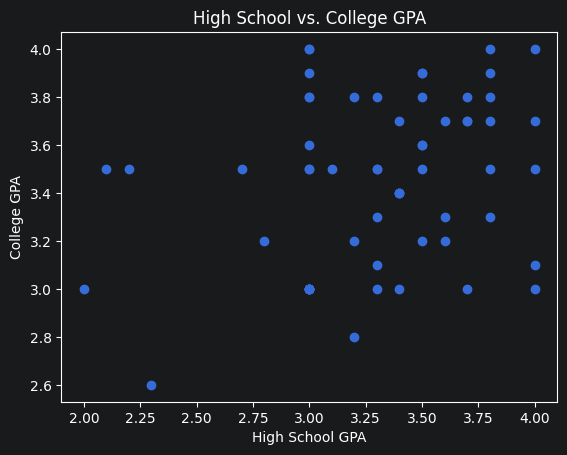

High School GPA: Mean=3.308, Std Dev=0.456
College GPA: Mean=3.453, Std Dev=0.349
count    60.000000
mean      3.308333
std       0.459658
min       2.000000
25%       3.000000
50%       3.350000
75%       3.625000
max       4.000000
Name: hsgpa, dtype: float64


In [35]:
# First, create a scatter plot of the two variables
hs_gpa = students['hsgpa']
co_gpa = students['cogpa']
plt.scatter(hs_gpa, co_gpa)
plt.xlabel('High School GPA')
plt.ylabel('College GPA')
plt.title('High School vs. College GPA')
plt.show()
# Print mean and standard deviation
print('High School GPA: Mean=%.3f, Std Dev=%.3f' % (np.mean(hs_gpa), np.std(hs_gpa)))
print('College GPA: Mean=%.3f, Std Dev=%.3f' % (np.mean(co_gpa), np.std(co_gpa)))
print(students['hsgpa'].describe().T)


In [38]:
# Calculate the correlation between the two variables
corr = scipy.stats.pearsonr(hs_gpa, co_gpa)
print('Correlation between High School GPA and College GPA: %.3f' % corr[0])

Correlation between High School GPA and College GPA: 0.278


In [42]:
# Reshape data for regression
hs_gpa_lm = hs_gpa.values.reshape(-1,1)

# Simple linear regression
lm = LinearRegression()
lm.fit(hs_gpa_lm, co_gpa)
# Print the slope and intercept to get the equation 
print('Intercept: %.3f' % lm.intercept_)
print('Slope: %.3f' % lm.coef_[0])

Intercept: 2.749
Slope: 0.213


The equation for a simple linear regression is:

$$y = \alpha + \beta{x}$$

Therefore the equation for this model is:

$$College GPA = 2.75 + 0.213{High School GPA}$$

In [43]:
# Find predicted college GPA if high school GPA is 4.0
pred_co_gpa = 2.749 + (0.213*4.0)
print('The predicted college GPA is: %.1f' % pred_co_gpa)

The predicted college GPA is: 3.6
